Loaded existing thermalized state:
/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v2/FCC/n_cells_30/rho_0.560/kT_0.720/nsteps_1000000/seed_1/randomization.gsd
Loaded state
n_fcc_cells: 30
N:               108000
target_rho:      0.56
actual_rho:      0.5600000039676765
kT:              0.72
phase_separated: True

start 0: success=True, nll=12122.549
start 1: success=True, nll=10738.038
start 2: success=True, nll=10687.045
Poisson + Gaussian + Gaussian model parameters
success:      True
message:      CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
nll:          10687

nbins:        15
n_voxels:     3375
voxel_volume: 57.1429

Gas Poisson
----------------------------------------------------------------------
w_g:                 0.149875
lambda_g_count:      0.000243319
rho_g:               4.25808e-06

Interface Gaussian
----------------------------------------------------------------------
w_i:                 0.206194
mu_i_count:          0.000343319
sigma_i_count:      

,component,distribution,weight,mean_count,sigma_count,mean_density,sigma_density
0,gas,Poisson,0.149875,0.000243,0.015599,0.000004,0.000273
1,interface,Gaussian,0.206194,0.000343,19.483471,0.000006,0.340961
2,liquid,Gaussian,0.643931,45.298310,2.858672,0.792720,0.050027


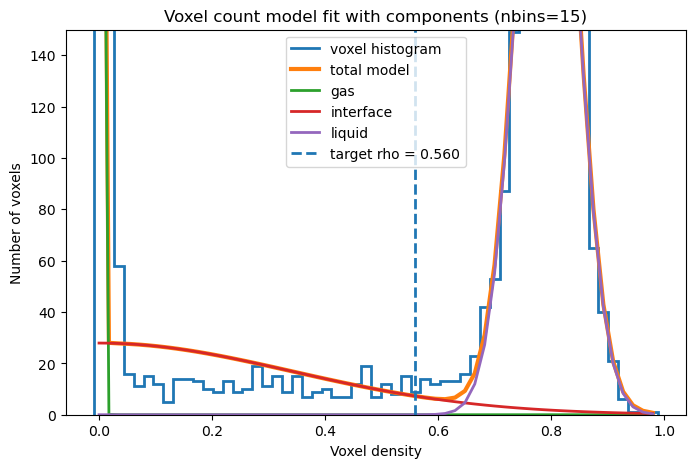

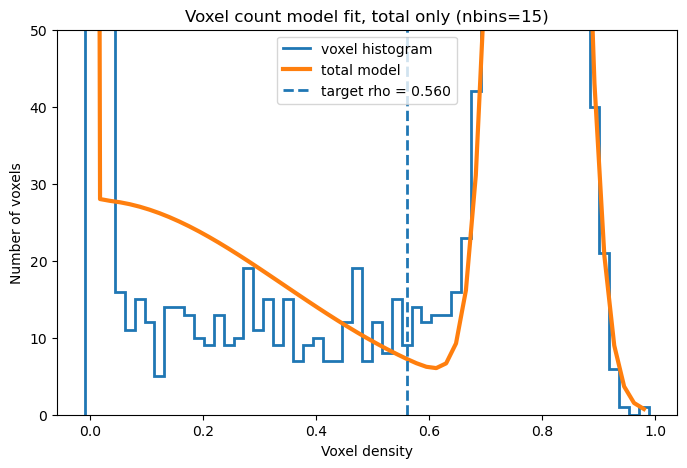

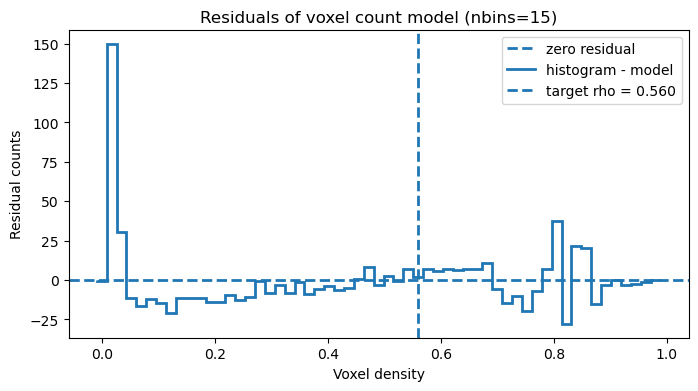

In [13]:
# ============================================================
# Simplified voxel count model fit
#
# Model:
#   gas        = Poisson
#   interface  = binned Gaussian
#   liquid     = binned Gaussian
#
# Fit is done in integer voxel-count space.
# Parameters are printed in both count space and density space.
# ============================================================

import importlib
import ipympl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from scipy.special import gammaln, logsumexp
from scipy.stats import norm

import md_Helpers.Simulation_Helpers as sh
import md_Helpers.Logging_Helpers as lh
import md_Helpers.viz_helpers as vh

importlib.reload(sh)
importlib.reload(lh)
importlib.reload(vh)

# ============================================================
# Probability helpers
# ============================================================

def poisson_probs(k_values, lam):
    """
    Poisson probability for integer voxel counts.
    """

    k_values = np.asarray(k_values, dtype=np.float64)
    lam = max(float(lam), 1e-12)

    log_probs = (
        k_values * np.log(lam)
        - lam
        - gammaln(k_values + 1.0)
    )

    return np.exp(log_probs)


def binned_gaussian_probs(k_values, mu, sigma):
    """
    Probability for integer count k from a continuous Gaussian
    integrated over [k - 1/2, k + 1/2].
    """

    k_values = np.asarray(k_values, dtype=np.float64)

    mu = float(mu)
    sigma = max(float(sigma), 1e-12)

    lower = k_values - 0.5
    upper = k_values + 0.5

    probs = (
        norm.cdf((upper - mu) / sigma)
        - norm.cdf((lower - mu) / sigma)
    )

    # Renormalize because negative particle counts are unphysical.
    nonnegative_mass = (
        1.0
        - norm.cdf((-0.5 - mu) / sigma)
    )

    if nonnegative_mass > 0:
        probs = probs / nonnegative_mass

    return probs


def safe_nll(hist_counts, probs):
    """
    Negative log likelihood for histogram counts.
    """

    probs = np.asarray(probs, dtype=np.float64)

    probs = np.clip(
        probs,
        1e-300,
        None,
    )

    return float(
        -np.sum(hist_counts * np.log(probs))
    )


def softmax(logits):
    """
    Convert arbitrary logits into positive weights that sum to 1.
    """

    logits = np.asarray(logits, dtype=np.float64)

    return np.exp(
        logits - logsumexp(logits)
    )


# ============================================================
# Voxel count histogram
# ============================================================

def get_voxel_count_histogram(obj, nbins=15):
    """
    Compute the histogram of integer particle counts per voxel.
    """

    voxel_densities, voxel_counts, voxel_volume = vh.compute_voxel_densities(
        obj,
        nbins=nbins,
    )

    voxel_counts = np.asarray(
        voxel_counts,
        dtype=np.float64,
    )

    voxel_counts_int = np.rint(
        voxel_counts
    ).astype(int)

    if not np.allclose(voxel_counts, voxel_counts_int):
        raise ValueError(
            "voxel_counts were not integer-like. Something is wrong."
        )

    max_count = int(voxel_counts_int.max())

    k_values = np.arange(
        0,
        max_count + 1,
        dtype=int,
    )

    hist_counts = np.bincount(
        voxel_counts_int,
        minlength=max_count + 1,
    )

    hist_info = {
        "voxel_densities": voxel_densities,
        "voxel_counts": voxel_counts_int,
        "voxel_volume": float(voxel_volume),

        "k_values": k_values,
        "hist_counts": hist_counts,

        "n_voxels": int(len(voxel_counts_int)),
        "nbins": int(nbins),
    }

    return hist_info


# ============================================================
# Model parameter helpers
# ============================================================

def unpack_pgg_params(theta):
    """
    Convert optimizer parameters into physical model parameters.

    Enforced:
    - weights are positive and sum to 1
    - lambda_g > 0
    - lambda_g < mu_i < mu_l
    - sigma_i > 0
    - sigma_l > 0
    """

    weights = softmax(theta[0:3])

    lambda_g = np.exp(theta[3])

    delta_i = np.exp(theta[4])
    delta_l = np.exp(theta[5])

    mu_i = lambda_g + delta_i
    mu_l = mu_i + delta_l

    sigma_i = np.exp(theta[6])
    sigma_l = np.exp(theta[7])

    params = {
        "w_g": float(weights[0]),
        "w_i": float(weights[1]),
        "w_l": float(weights[2]),

        "lambda_g": float(lambda_g),

        "mu_i": float(mu_i),
        "sigma_i": float(sigma_i),

        "mu_l": float(mu_l),
        "sigma_l": float(sigma_l),
    }

    return params


def make_pgg_start(
    weights,
    lambda_g,
    mu_i,
    mu_l,
    sigma_i,
    sigma_l,
):
    """
    Make one optimizer starting point from physical guesses.
    """

    weights = np.asarray(weights, dtype=np.float64)
    weights = weights / np.sum(weights)

    lambda_g = max(float(lambda_g), 1e-4)

    mu_i = max(
        float(mu_i),
        lambda_g + 1e-3,
    )

    mu_l = max(
        float(mu_l),
        mu_i + 1e-3,
    )

    sigma_i = max(float(sigma_i), 0.25)
    sigma_l = max(float(sigma_l), 0.25)

    theta = np.array(
        [
            np.log(weights[0]),
            np.log(weights[1]),
            np.log(weights[2]),

            np.log(lambda_g),
            np.log(mu_i - lambda_g),
            np.log(mu_l - mu_i),

            np.log(sigma_i),
            np.log(sigma_l),
        ],
        dtype=np.float64,
    )

    return theta


def pgg_component_probs(k_values, params):
    """
    Return gas, interface, liquid, and total model probabilities.
    """

    p_g = poisson_probs(
        k_values=k_values,
        lam=params["lambda_g"],
    )

    p_i = binned_gaussian_probs(
        k_values=k_values,
        mu=params["mu_i"],
        sigma=params["sigma_i"],
    )

    p_l = binned_gaussian_probs(
        k_values=k_values,
        mu=params["mu_l"],
        sigma=params["sigma_l"],
    )

    total_probs = (
        params["w_g"] * p_g
        + params["w_i"] * p_i
        + params["w_l"] * p_l
    )

    return p_g, p_i, p_l, total_probs


# ============================================================
# Fit model
# ============================================================

def fit_pgg_voxel_count_model(
    obj,
    nbins=15,
    print_starts=False,
):
    """
    Fit Poisson + Gaussian + Gaussian to the voxel-count histogram.

    Returns a dictionary containing:
    - histogram info
    - fitted count-space parameters
    - fitted density-space parameters
    - model probabilities
    """

    hist_info = get_voxel_count_histogram(
        obj=obj,
        nbins=nbins,
    )

    k_values = np.asarray(
        hist_info["k_values"],
        dtype=np.float64,
    )

    hist_counts = np.asarray(
        hist_info["hist_counts"],
        dtype=np.float64,
    )

    voxel_volume = float(hist_info["voxel_volume"])

    expanded_counts = np.repeat(
        k_values,
        hist_counts.astype(int),
    )

    std_count = float(
        np.std(expanded_counts, ddof=1)
    )

    q01, q05, q20, q50, q80, q95, q99 = np.percentile(
        expanded_counts,
        [1, 5, 20, 50, 80, 95, 99],
    )

    max_scale = max(
        float(k_values.max()) + 10.0,
        10.0,
    )

    def objective(theta):
        params = unpack_pgg_params(theta)

        _, _, _, total_probs = pgg_component_probs(
            k_values=k_values,
            params=params,
        )

        return safe_nll(
            hist_counts=hist_counts,
            probs=total_probs,
        )

    # ------------------------------------------------------------
    # Why multiple starts?
    #
    # This fit is nonlinear. Different initial guesses can land in
    # different local minima. We try a few reasonable guesses and keep
    # the best fit.
    # ------------------------------------------------------------
    physical_starts = [
        # weights, lambda_g, mu_i, mu_l, sigma_i, sigma_l
        ([0.20, 0.20, 0.60], q05, q50, q95, 1.0, max(std_count / 2.0, 1.0)),
        ([0.30, 0.20, 0.50], q05, q50, q80, 1.0, max(std_count / 2.0, 1.0)),
        ([0.10, 0.10, 0.80], q01, q20, q99, 1.0, max(std_count / 2.0, 1.0)),
    ]

    theta_starts = []

    for start in physical_starts:
        weights, lambda_g, mu_i, mu_l, sigma_i, sigma_l = start

        theta_starts.append(
            make_pgg_start(
                weights=weights,
                lambda_g=lambda_g,
                mu_i=mu_i,
                mu_l=mu_l,
                sigma_i=sigma_i,
                sigma_l=sigma_l,
            )
        )

    bounds = [
        (-10.0, 10.0),                      # gas weight logit
        (-10.0, 10.0),                      # interface weight logit
        (-10.0, 10.0),                      # liquid weight logit

        (np.log(1e-4), np.log(max_scale)),  # lambda_g
        (np.log(1e-4), np.log(max_scale)),  # mu_i - lambda_g
        (np.log(1e-4), np.log(max_scale)),  # mu_l - mu_i

        (np.log(0.25), np.log(max_scale)),  # sigma_i
        (np.log(0.25), np.log(max_scale)),  # sigma_l
    ]

    best = None

    for i, theta0 in enumerate(theta_starts):
        res = minimize(
            objective,
            theta0,
            method="L-BFGS-B",
            bounds=bounds,
            options={
                "maxiter": 5000,
            },
        )

        if print_starts:
            print(
                f"start {i}: "
                f"success={res.success}, "
                f"nll={res.fun:.3f}"
            )

        if best is None or res.fun < best.fun:
            best = res

    params = unpack_pgg_params(best.x)

    p_g, p_i, p_l, total_probs = pgg_component_probs(
        k_values=k_values,
        params=params,
    )

    nll = safe_nll(
        hist_counts=hist_counts,
        probs=total_probs,
    )

    # ------------------------------------------------------------
    # Add density-space parameters
    # ------------------------------------------------------------
    params["rho_g"] = params["lambda_g"] / voxel_volume

    params["rho_i"] = params["mu_i"] / voxel_volume
    params["rho_sigma_i"] = params["sigma_i"] / voxel_volume

    params["rho_l"] = params["mu_l"] / voxel_volume
    params["rho_sigma_l"] = params["sigma_l"] / voxel_volume

    params["rho_l_minus_rho_g"] = (
        params["rho_l"] - params["rho_g"]
    )

    fit = {
        **hist_info,

        "model_name": "poisson_gaussian_gaussian",

        "params": params,

        "nll": float(nll),
        "success": bool(best.success),
        "message": best.message,

        "probs": total_probs,

        "component_probs": {
            "gas": p_g,
            "interface": p_i,
            "liquid": p_l,
        },
    }

    return fit


# ============================================================
# Print model parameters
# ============================================================

def print_pgg_model_parameters(fit):
    """
    Print only the fitted model parameters.
    """

    p = fit["params"]

    print("Poisson + Gaussian + Gaussian model parameters")
    print("=" * 70)
    print(f"success:      {fit['success']}")
    print(f"message:      {fit['message']}")
    print(f"nll:          {fit['nll']:.6g}")
    print()
    print(f"nbins:        {fit['nbins']}")
    print(f"n_voxels:     {fit['n_voxels']}")
    print(f"voxel_volume: {fit['voxel_volume']:.6g}")
    print()

    print("Gas Poisson")
    print("-" * 70)
    print(f"w_g:                 {p['w_g']:.6g}")
    print(f"lambda_g_count:      {p['lambda_g']:.6g}")
    print(f"rho_g:               {p['rho_g']:.6g}")
    print()

    print("Interface Gaussian")
    print("-" * 70)
    print(f"w_i:                 {p['w_i']:.6g}")
    print(f"mu_i_count:          {p['mu_i']:.6g}")
    print(f"sigma_i_count:       {p['sigma_i']:.6g}")
    print(f"rho_i:               {p['rho_i']:.6g}")
    print(f"rho_sigma_i:         {p['rho_sigma_i']:.6g}")
    print()

    print("Liquid Gaussian")
    print("-" * 70)
    print(f"w_l:                 {p['w_l']:.6g}")
    print(f"mu_l_count:          {p['mu_l']:.6g}")
    print(f"sigma_l_count:       {p['sigma_l']:.6g}")
    print(f"rho_l:               {p['rho_l']:.6g}")
    print(f"rho_sigma_l:         {p['rho_sigma_l']:.6g}")
    print()

    print("Separation")
    print("-" * 70)
    print(f"rho_l - rho_g:       {p['rho_l_minus_rho_g']:.6g}")
    print("=" * 70)


def make_pgg_parameter_dataframe(fit):
    """
    Return model parameters as a dataframe.
    """

    p = fit["params"]

    rows = [
        {
            "component": "gas",
            "distribution": "Poisson",
            "weight": p["w_g"],
            "mean_count": p["lambda_g"],
            "sigma_count": np.sqrt(p["lambda_g"]),
            "mean_density": p["rho_g"],
            "sigma_density": np.sqrt(p["lambda_g"]) / fit["voxel_volume"],
        },
        {
            "component": "interface",
            "distribution": "Gaussian",
            "weight": p["w_i"],
            "mean_count": p["mu_i"],
            "sigma_count": p["sigma_i"],
            "mean_density": p["rho_i"],
            "sigma_density": p["rho_sigma_i"],
        },
        {
            "component": "liquid",
            "distribution": "Gaussian",
            "weight": p["w_l"],
            "mean_count": p["mu_l"],
            "sigma_count": p["sigma_l"],
            "mean_density": p["rho_l"],
            "sigma_density": p["rho_sigma_l"],
        },
    ]

    return pd.DataFrame(rows)


# ============================================================
# Plot fit
# ============================================================

def plot_pgg_fit(fit, show_components=True, y_max=None):
    """
    Plot voxel histogram and fitted PGG model.

    Makes three plots:
    1. Full plot with components
    2. Clean plot with only voxel histogram + total model
    3. Residual plot: histogram - total model
    """

    k_values = fit["k_values"]
    hist_counts = fit["hist_counts"]
    voxel_volume = fit["voxel_volume"]
    n_voxels = fit["n_voxels"]
    nbins = fit["nbins"]

    x_centers = k_values / voxel_volume

    count_edges = np.arange(
        k_values.min() - 0.5,
        k_values.max() + 1.5,
        1.0,
    )

    density_edges = count_edges / voxel_volume

    p = fit["params"]

    p_total = fit["probs"]

    p_g = fit["component_probs"]["gas"]
    p_i = fit["component_probs"]["interface"]
    p_l = fit["component_probs"]["liquid"]

    model_counts = n_voxels * p_total

    residual_counts = hist_counts - model_counts

    target_rho_from_metadata = lh.read_hdf5_log(
        result["paths"]["log_path"]
    )["metadata"]["attrs"]["target_rho"]

    # ============================================================
    # Plot 1: full model with components
    # ============================================================

    plt.figure(figsize=(8, 5))

    plt.stairs(
        hist_counts,
        edges=density_edges,
        label="voxel histogram",
        linewidth=2,
    )

    plt.plot(
        x_centers,
        model_counts,
        linewidth=3,
        label="total model",
    )

    if show_components:
        plt.plot(
            x_centers,
            n_voxels * p["w_g"] * p_g,
            linewidth=2,
            label="gas",
        )

        plt.plot(
            x_centers,
            n_voxels * p["w_i"] * p_i,
            linewidth=2,
            label="interface",
        )

        plt.plot(
            x_centers,
            n_voxels * p["w_l"] * p_l,
            linewidth=2,
            label="liquid",
        )

    plt.axvline(
        target_rho_from_metadata,
        linestyle="--",
        linewidth=2,
        label=f"target rho = {target_rho_from_metadata:.3f}",
    )

    plt.xlabel("Voxel density")
    plt.ylabel("Number of voxels")
    plt.title(f"Voxel count model fit with components (nbins={nbins})")
    if y_max is not None:
        plt.ylim(
            top=3*y_max,
        )
    plt.legend()
    plt.show()

    # ============================================================
    # Plot 2: clean plot, histogram + total model only
    # ============================================================

    plt.figure(figsize=(8, 5))

    plt.stairs(
        hist_counts,
        edges=density_edges,
        label="voxel histogram",
        linewidth=2,
    )

    plt.plot(
        x_centers,
        model_counts,
        linewidth=3,
        label="total model",
    )

    plt.axvline(
        target_rho_from_metadata,
        linestyle="--",
        linewidth=2,
        label=f"target rho = {target_rho_from_metadata:.3f}",
    )

    plt.xlabel("Voxel density")
    plt.ylabel("Number of voxels")
    plt.title(f"Voxel count model fit, total only (nbins={nbins})")
    if y_max is not None:
        plt.ylim(
            top=y_max,
        )
    plt.legend()
    plt.show()

    # ============================================================
    # Plot 3: residuals, histogram - total model
    # ============================================================

    plt.figure(figsize=(8, 4))

    plt.axhline(
        0.0,
        linestyle="--",
        linewidth=2,
        label="zero residual",
    )

    plt.stairs(
        residual_counts,
        edges=density_edges,
        linewidth=2,
        label="histogram - model",
    )

    plt.axvline(
        target_rho_from_metadata,
        linestyle="--",
        linewidth=2,
        label=f"target rho = {target_rho_from_metadata:.3f}",
    )

    plt.xlabel("Voxel density")
    plt.ylabel("Residual counts")
    plt.title(f"Residuals of voxel count model (nbins={nbins})")
    plt.legend()
    plt.show()


# ============================================================
# Load or make state
# ============================================================
target_rho = 0.56
kT = 0.72
nsteps = 1_000_000


# Set True only if you want to see each optimizer start.
print_starts = True
fit_nbins = 15
y_max = 50


result = sh.get_or_make_thermalized_state(
    n_fcc_cells=30,
    target_rho=target_rho,
    kT=kT,
    nsteps=nsteps,
    overwrite=False,
)


# ============================================================
# Print quick metadata
# ============================================================

log = lh.read_hdf5_log(
    result["paths"]["log_path"]
)

metadata = log["metadata"]["attrs"]

print("Loaded state")
print("=" * 70)
print(f"n_fcc_cells: 30")
print(f"N:               {metadata.get('N')}")
print(f"target_rho:      {metadata.get('target_rho')}")
print(f"actual_rho:      {metadata.get('actual_rho')}")
print(f"kT:              {metadata.get('kT')}")
print(f"phase_separated: {metadata.get('phase_separated')}")
print("=" * 70)
print()




# ============================================================
# Fit model
# ============================================================


fit = fit_pgg_voxel_count_model(
    result,
    nbins=fit_nbins,
    print_starts=print_starts,
)

print_pgg_model_parameters(
    fit,
)

params_df = make_pgg_parameter_dataframe(
    fit,
)

display(params_df)

plot_pgg_fit(
    fit,
    show_components=True,
    y_max=y_max
)

Loaded existing thermalized state:
/exp/e961/data/MDsims-data/pnichols/Thermalized_States_v2/FCC/n_cells_30/rho_0.560/kT_0.700/nsteps_1000000/seed_1/randomization.gsd
Loaded state
n_fcc_cells: 30
N:               108000
target_rho:      0.56
actual_rho:      0.5600000039676765
kT:              0.7
phase_separated: True

start 0: success=True, nll=10476.912
start 1: success=False, nll=12262.454
start 2: success=True, nll=10257.911
start 3: success=False, nll=12586.785
start 4: success=True, nll=10476.911
Poisson + Linear + Gaussian model parameters
success:      True
message:      CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
nll:          10257.9

nbins:        15
n_voxels:     3375
voxel_volume: 57.1429

Gas Poisson
----------------------------------------------------------------------
w_g:                 0.227215
lambda_g_count:      0.304065
rho_g:               0.00532114

Interface Linear Bridge
----------------------------------------------------------------------
w_i:   

,component,distribution,weight,mean_count,sigma_count,mean_density,sigma_density,rho_min,rho_max,end_ratio
0,gas,Poisson,0.227215,0.304065,0.551421,0.005321,0.009650,NaN,NaN,NaN
1,interface,Linear bridge,0.129976,19.526823,12.345453,0.341719,0.216045,0.005339,0.786747,0.415779
2,liquid,Gaussian,0.642809,45.833203,2.817276,0.802081,0.049302,NaN,NaN,NaN


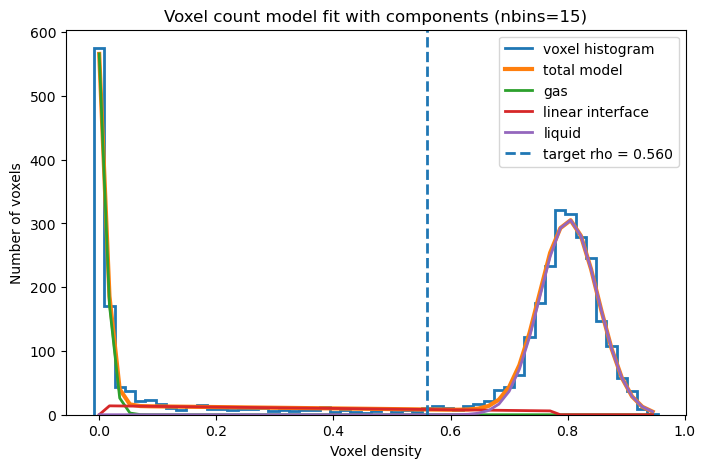

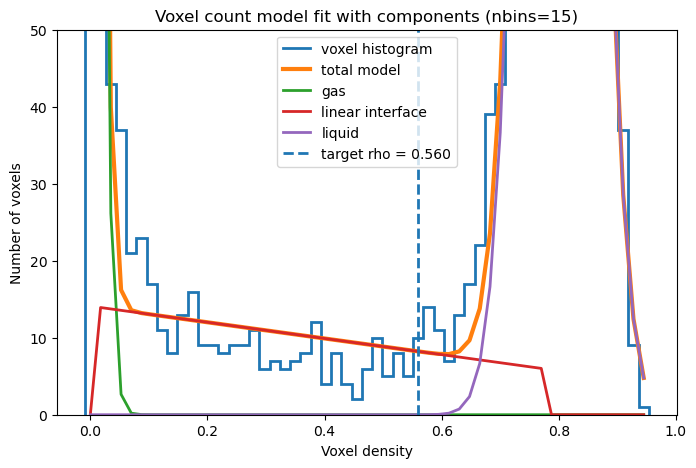

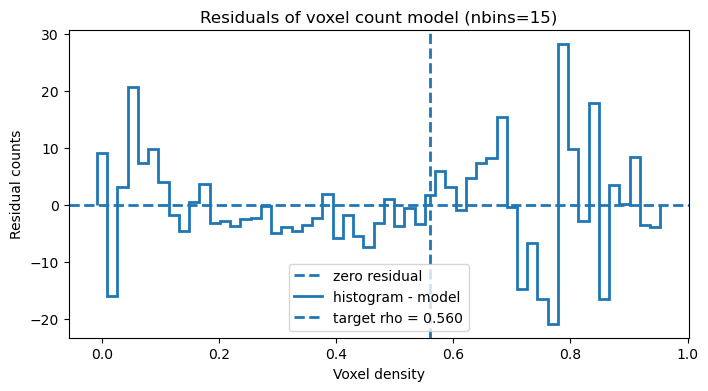

In [23]:
# ============================================================
# Simplified voxel count model fit
#
# Model:
#   gas        = Poisson
#   interface  = linear bridge
#   liquid     = binned Gaussian
#
# Fit is done in integer voxel-count space.
# Parameters are printed in both count space and density space.
# ============================================================

import importlib
import ipympl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from scipy.special import gammaln, logsumexp
from scipy.stats import norm

import md_Helpers.Simulation_Helpers as sh
import md_Helpers.Logging_Helpers as lh
import md_Helpers.viz_helpers as vh

importlib.reload(sh)
importlib.reload(lh)
importlib.reload(vh)


# ============================================================
# Probability helpers
# ============================================================

def poisson_probs(k_values, lam):
    """
    Poisson probability for integer voxel counts.
    """

    k_values = np.asarray(k_values, dtype=np.float64)
    lam = max(float(lam), 1e-12)

    log_probs = (
        k_values * np.log(lam)
        - lam
        - gammaln(k_values + 1.0)
    )

    return np.exp(log_probs)


def binned_gaussian_probs(k_values, mu, sigma):
    """
    Probability for integer count k from a continuous Gaussian
    integrated over [k - 1/2, k + 1/2].
    """

    k_values = np.asarray(k_values, dtype=np.float64)

    mu = float(mu)
    sigma = max(float(sigma), 1e-12)

    lower = k_values - 0.5
    upper = k_values + 0.5

    probs = (
        norm.cdf((upper - mu) / sigma)
        - norm.cdf((lower - mu) / sigma)
    )

    # Renormalize because negative particle counts are unphysical.
    nonnegative_mass = (
        1.0
        - norm.cdf((-0.5 - mu) / sigma)
    )

    if nonnegative_mass > 0:
        probs = probs / nonnegative_mass

    return probs


def linear_count_probs(
    k_values,
    k_min,
    k_max,
    end_ratio,
):
    """
    Linear probability bridge over integer count bins.

    The unnormalized interface shape is linear between k_min and k_max.

    end_ratio controls the height at k_max relative to k_min:

        end_ratio < 1  -> decreases from gas side to liquid side
        end_ratio = 1  -> uniform
        end_ratio > 1  -> increases from gas side to liquid side
    """

    k_values = np.asarray(k_values, dtype=np.float64)

    k_min = float(k_min)
    k_max = float(k_max)

    end_ratio = max(
        float(end_ratio),
        1e-8,
    )

    probs = np.zeros_like(
        k_values,
        dtype=np.float64,
    )

    mask = (
        (k_values >= k_min)
        & (k_values <= k_max)
    )

    if np.sum(mask) == 0:
        return probs

    if k_max <= k_min:
        probs[mask] = 1.0

    else:
        t = (
            (k_values[mask] - k_min)
            / (k_max - k_min)
        )

        probs[mask] = (
            (1.0 - t)
            + end_ratio * t
        )

    probs = np.clip(
        probs,
        1e-300,
        None,
    )

    probs = probs / np.sum(probs)

    return probs


def safe_nll(hist_counts, probs):
    """
    Negative log likelihood for histogram counts.
    """

    probs = np.asarray(probs, dtype=np.float64)

    probs = np.clip(
        probs,
        1e-300,
        None,
    )

    return float(
        -np.sum(hist_counts * np.log(probs))
    )


def softmax(logits):
    """
    Convert arbitrary logits into positive weights that sum to 1.
    """

    logits = np.asarray(logits, dtype=np.float64)

    return np.exp(
        logits - logsumexp(logits)
    )


# ============================================================
# Voxel count histogram
# ============================================================

def get_voxel_count_histogram(obj, nbins=15):
    """
    Compute the histogram of integer particle counts per voxel.
    """

    voxel_densities, voxel_counts, voxel_volume = vh.compute_voxel_densities(
        obj,
        nbins=nbins,
    )

    voxel_counts = np.asarray(
        voxel_counts,
        dtype=np.float64,
    )

    voxel_counts_int = np.rint(
        voxel_counts
    ).astype(int)

    if not np.allclose(voxel_counts, voxel_counts_int):
        raise ValueError(
            "voxel_counts were not integer-like. Something is wrong."
        )

    max_count = int(voxel_counts_int.max())

    k_values = np.arange(
        0,
        max_count + 1,
        dtype=int,
    )

    hist_counts = np.bincount(
        voxel_counts_int,
        minlength=max_count + 1,
    )

    hist_info = {
        "voxel_densities": voxel_densities,
        "voxel_counts": voxel_counts_int,
        "voxel_volume": float(voxel_volume),

        "k_values": k_values,
        "hist_counts": hist_counts,

        "n_voxels": int(len(voxel_counts_int)),
        "nbins": int(nbins),
    }

    return hist_info


# ============================================================
# Model parameter helpers
# ============================================================

def unpack_pgg_params(theta):
    """
    Convert optimizer parameters into physical model parameters.

    Enforced:
    - weights are positive and sum to 1
    - lambda_g > 0
    - lambda_g < k_i_min < k_i_max < mu_l
    - sigma_l > 0
    - interface_end_ratio > 0
    """

    weights = softmax(theta[0:3])

    lambda_g = np.exp(theta[3])

    delta_i_start = np.exp(theta[4])
    width_i = np.exp(theta[5])
    delta_l = np.exp(theta[6])

    k_i_min = lambda_g + delta_i_start
    k_i_max = k_i_min + width_i
    mu_l = k_i_max + delta_l

    sigma_l = np.exp(theta[7])

    interface_end_ratio = np.exp(theta[8])

    params = {
        "w_g": float(weights[0]),
        "w_i": float(weights[1]),
        "w_l": float(weights[2]),

        "lambda_g": float(lambda_g),

        "k_i_min": float(k_i_min),
        "k_i_max": float(k_i_max),
        "interface_end_ratio": float(interface_end_ratio),

        "mu_l": float(mu_l),
        "sigma_l": float(sigma_l),
    }

    return params


def make_pgg_start(
    weights,
    lambda_g,
    k_i_min,
    k_i_max,
    mu_l,
    sigma_l,
    interface_end_ratio,
):
    """
    Make one optimizer starting point from physical guesses.
    """

    weights = np.asarray(weights, dtype=np.float64)
    weights = weights / np.sum(weights)

    lambda_g = max(float(lambda_g), 1e-4)

    k_i_min = max(
        float(k_i_min),
        lambda_g + 1e-3,
    )

    k_i_max = max(
        float(k_i_max),
        k_i_min + 1e-3,
    )

    mu_l = max(
        float(mu_l),
        k_i_max + 1e-3,
    )

    sigma_l = max(float(sigma_l), 0.25)

    interface_end_ratio = max(
        float(interface_end_ratio),
        1e-4,
    )

    theta = np.array(
        [
            np.log(weights[0]),
            np.log(weights[1]),
            np.log(weights[2]),

            np.log(lambda_g),

            np.log(k_i_min - lambda_g),
            np.log(k_i_max - k_i_min),
            np.log(mu_l - k_i_max),

            np.log(sigma_l),

            np.log(interface_end_ratio),
        ],
        dtype=np.float64,
    )

    return theta


def pgg_component_probs(k_values, params):
    """
    Return gas, interface, liquid, and total model probabilities.
    """

    p_g = poisson_probs(
        k_values=k_values,
        lam=params["lambda_g"],
    )

    p_i = linear_count_probs(
        k_values=k_values,
        k_min=params["k_i_min"],
        k_max=params["k_i_max"],
        end_ratio=params["interface_end_ratio"],
    )

    p_l = binned_gaussian_probs(
        k_values=k_values,
        mu=params["mu_l"],
        sigma=params["sigma_l"],
    )

    total_probs = (
        params["w_g"] * p_g
        + params["w_i"] * p_i
        + params["w_l"] * p_l
    )

    return p_g, p_i, p_l, total_probs


# ============================================================
# Fit model
# ============================================================

def fit_pgg_voxel_count_model(
    obj,
    nbins=15,
    print_starts=False,
):
    """
    Fit Poisson + linear bridge + Gaussian to the voxel-count histogram.

    Returns a dictionary containing:
    - histogram info
    - fitted count-space parameters
    - fitted density-space parameters
    - model probabilities
    """

    hist_info = get_voxel_count_histogram(
        obj=obj,
        nbins=nbins,
    )

    k_values = np.asarray(
        hist_info["k_values"],
        dtype=np.float64,
    )

    hist_counts = np.asarray(
        hist_info["hist_counts"],
        dtype=np.float64,
    )

    voxel_volume = float(hist_info["voxel_volume"])

    expanded_counts = np.repeat(
        k_values,
        hist_counts.astype(int),
    )

    std_count = float(
        np.std(expanded_counts, ddof=1)
    )

    q01, q05, q20, q50, q80, q90, q95, q99 = np.percentile(
        expanded_counts,
        [1, 5, 20, 50, 80, 90, 95, 99],
    )

    max_scale = max(
        float(k_values.max()) + 10.0,
        10.0,
    )

    def objective(theta):
        params = unpack_pgg_params(theta)

        _, _, _, total_probs = pgg_component_probs(
            k_values=k_values,
            params=params,
        )

        return safe_nll(
            hist_counts=hist_counts,
            probs=total_probs,
        )

    # ------------------------------------------------------------
    # Why multiple starts?
    #
    # This fit is nonlinear. Different initial guesses can land in
    # different local minima. We try a few reasonable guesses and keep
    # the best fit.
    # ------------------------------------------------------------
    physical_starts = [
        # weights, lambda_g, k_i_min, k_i_max, mu_l, sigma_l, interface_end_ratio

        # Decreasing interface bridge
        ([0.20, 0.30, 0.50], q01, q05, q80, q95, max(std_count / 2.0, 1.0), 0.20),

        # Nearly flat interface bridge
        ([0.20, 0.30, 0.50], q01, q05, q80, q95, max(std_count / 2.0, 1.0), 1.00),

        # Wider interface bridge
        ([0.25, 0.35, 0.40], q01, q05, q90, q95, max(std_count / 2.0, 1.0), 0.20),

        # More liquid-heavy
        ([0.10, 0.20, 0.70], q01, q20, q80, q99, max(std_count / 2.0, 1.0), 0.50),

        # More gas/interface-heavy
        ([0.30, 0.40, 0.30], q01, q05, q80, q95, max(std_count / 2.0, 1.0), 0.20),
    ]

    theta_starts = []

    for start in physical_starts:
        (
            weights,
            lambda_g,
            k_i_min,
            k_i_max,
            mu_l,
            sigma_l,
            interface_end_ratio,
        ) = start

        theta_starts.append(
            make_pgg_start(
                weights=weights,
                lambda_g=lambda_g,
                k_i_min=k_i_min,
                k_i_max=k_i_max,
                mu_l=mu_l,
                sigma_l=sigma_l,
                interface_end_ratio=interface_end_ratio,
            )
        )

    bounds = [
        (-10.0, 10.0),                      # gas weight logit
        (-10.0, 10.0),                      # interface weight logit
        (-10.0, 10.0),                      # liquid weight logit

        (np.log(1e-4), np.log(max_scale)),  # lambda_g

        (np.log(1e-4), np.log(max_scale)),  # k_i_min - lambda_g
        (np.log(1e-4), np.log(max_scale)),  # k_i_max - k_i_min
        (np.log(1e-4), np.log(max_scale)),  # mu_l - k_i_max

        (np.log(0.25), np.log(max_scale)),  # sigma_l

        (np.log(0.02), np.log(50.0)),       # interface_end_ratio
    ]

    best = None

    for i, theta0 in enumerate(theta_starts):
        res = minimize(
            objective,
            theta0,
            method="L-BFGS-B",
            bounds=bounds,
            options={
                "maxiter": 5000,
            },
        )

        if print_starts:
            print(
                f"start {i}: "
                f"success={res.success}, "
                f"nll={res.fun:.3f}"
            )

        if best is None or res.fun < best.fun:
            best = res

    params = unpack_pgg_params(best.x)

    p_g, p_i, p_l, total_probs = pgg_component_probs(
        k_values=k_values,
        params=params,
    )

    nll = safe_nll(
        hist_counts=hist_counts,
        probs=total_probs,
    )

    # ------------------------------------------------------------
    # Add density-space parameters
    # ------------------------------------------------------------
    params["rho_g"] = params["lambda_g"] / voxel_volume

    params["rho_i_min"] = params["k_i_min"] / voxel_volume
    params["rho_i_max"] = params["k_i_max"] / voxel_volume
    params["rho_i_width"] = (
        params["rho_i_max"] - params["rho_i_min"]
    )

    params["rho_l"] = params["mu_l"] / voxel_volume
    params["rho_sigma_l"] = params["sigma_l"] / voxel_volume

    params["rho_l_minus_rho_g"] = (
        params["rho_l"] - params["rho_g"]
    )

    fit = {
        **hist_info,

        "model_name": "poisson_linear_gaussian",

        "params": params,

        "nll": float(nll),
        "success": bool(best.success),
        "message": best.message,

        "probs": total_probs,

        "component_probs": {
            "gas": p_g,
            "interface": p_i,
            "liquid": p_l,
        },
    }

    return fit


# ============================================================
# Print model parameters
# ============================================================

def print_pgg_model_parameters(fit):
    """
    Print only the fitted model parameters.
    """

    p = fit["params"]

    print("Poisson + Linear + Gaussian model parameters")
    print("=" * 70)
    print(f"success:      {fit['success']}")
    print(f"message:      {fit['message']}")
    print(f"nll:          {fit['nll']:.6g}")
    print()
    print(f"nbins:        {fit['nbins']}")
    print(f"n_voxels:     {fit['n_voxels']}")
    print(f"voxel_volume: {fit['voxel_volume']:.6g}")
    print()

    print("Gas Poisson")
    print("-" * 70)
    print(f"w_g:                 {p['w_g']:.6g}")
    print(f"lambda_g_count:      {p['lambda_g']:.6g}")
    print(f"rho_g:               {p['rho_g']:.6g}")
    print()

    print("Interface Linear Bridge")
    print("-" * 70)
    print(f"w_i:                 {p['w_i']:.6g}")
    print(f"k_i_min_count:       {p['k_i_min']:.6g}")
    print(f"k_i_max_count:       {p['k_i_max']:.6g}")
    print(f"interface_end_ratio: {p['interface_end_ratio']:.6g}")
    print(f"rho_i_min:           {p['rho_i_min']:.6g}")
    print(f"rho_i_max:           {p['rho_i_max']:.6g}")
    print(f"rho_i_width:         {p['rho_i_width']:.6g}")
    print()

    print("Liquid Gaussian")
    print("-" * 70)
    print(f"w_l:                 {p['w_l']:.6g}")
    print(f"mu_l_count:          {p['mu_l']:.6g}")
    print(f"sigma_l_count:       {p['sigma_l']:.6g}")
    print(f"rho_l:               {p['rho_l']:.6g}")
    print(f"rho_sigma_l:         {p['rho_sigma_l']:.6g}")
    print()

    print("Separation")
    print("-" * 70)
    print(f"rho_l - rho_g:       {p['rho_l_minus_rho_g']:.6g}")
    print("=" * 70)


def make_pgg_parameter_dataframe(fit):
    """
    Return model parameters as a dataframe.
    """

    p = fit["params"]

    k_values = np.asarray(
        fit["k_values"],
        dtype=np.float64,
    )

    p_i = np.asarray(
        fit["component_probs"]["interface"],
        dtype=np.float64,
    )

    interface_mean_count = float(
        np.sum(k_values * p_i)
    )

    interface_sigma_count = float(
        np.sqrt(
            np.sum(
                p_i * (k_values - interface_mean_count)**2
            )
        )
    )

    rows = [
        {
            "component": "gas",
            "distribution": "Poisson",
            "weight": p["w_g"],
            "mean_count": p["lambda_g"],
            "sigma_count": np.sqrt(p["lambda_g"]),
            "mean_density": p["rho_g"],
            "sigma_density": np.sqrt(p["lambda_g"]) / fit["voxel_volume"],
        },
        {
            "component": "interface",
            "distribution": "Linear bridge",
            "weight": p["w_i"],
            "mean_count": interface_mean_count,
            "sigma_count": interface_sigma_count,
            "mean_density": interface_mean_count / fit["voxel_volume"],
            "sigma_density": interface_sigma_count / fit["voxel_volume"],
            "rho_min": p["rho_i_min"],
            "rho_max": p["rho_i_max"],
            "end_ratio": p["interface_end_ratio"],
        },
        {
            "component": "liquid",
            "distribution": "Gaussian",
            "weight": p["w_l"],
            "mean_count": p["mu_l"],
            "sigma_count": p["sigma_l"],
            "mean_density": p["rho_l"],
            "sigma_density": p["rho_sigma_l"],
        },
    ]

    return pd.DataFrame(rows)


# ============================================================
# Plot fit
# ============================================================

def plot_pgg_fit(fit, show_components=True, y_max=None):
    """
    Plot voxel histogram and fitted PGG model.

    Makes three plots:
    1. Full plot with components
    2. Clean plot with only voxel histogram + total model
    3. Residual plot: histogram - total model
    """

    k_values = fit["k_values"]
    hist_counts = fit["hist_counts"]
    voxel_volume = fit["voxel_volume"]
    n_voxels = fit["n_voxels"]
    nbins = fit["nbins"]

    x_centers = k_values / voxel_volume

    count_edges = np.arange(
        k_values.min() - 0.5,
        k_values.max() + 1.5,
        1.0,
    )

    density_edges = count_edges / voxel_volume

    p = fit["params"]

    p_total = fit["probs"]

    p_g = fit["component_probs"]["gas"]
    p_i = fit["component_probs"]["interface"]
    p_l = fit["component_probs"]["liquid"]

    model_counts = n_voxels * p_total

    residual_counts = hist_counts - model_counts

    target_rho_from_metadata = lh.read_hdf5_log(
        result["paths"]["log_path"]
    )["metadata"]["attrs"]["target_rho"]

    # ============================================================
    # Plot 1: full model with components
    # ============================================================

    plt.figure(figsize=(8, 5))

    plt.stairs(
        hist_counts,
        edges=density_edges,
        label="voxel histogram",
        linewidth=2,
    )

    plt.plot(
        x_centers,
        model_counts,
        linewidth=3,
        label="total model",
    )

    if show_components:
        plt.plot(
            x_centers,
            n_voxels * p["w_g"] * p_g,
            linewidth=2,
            label="gas",
        )

        plt.plot(
            x_centers,
            n_voxels * p["w_i"] * p_i,
            linewidth=2,
            label="linear interface",
        )

        plt.plot(
            x_centers,
            n_voxels * p["w_l"] * p_l,
            linewidth=2,
            label="liquid",
        )

    plt.axvline(
        target_rho_from_metadata,
        linestyle="--",
        linewidth=2,
        label=f"target rho = {target_rho_from_metadata:.3f}",
    )

    plt.xlabel("Voxel density")
    plt.ylabel("Number of voxels")
    plt.title(f"Voxel count model fit with components (nbins={nbins})")
    plt.legend()
    plt.show()

    # ============================================================
    # Plot 1: full model with components
    # ============================================================

    plt.figure(figsize=(8, 5))

    plt.stairs(
        hist_counts,
        edges=density_edges,
        label="voxel histogram",
        linewidth=2,
    )

    plt.plot(
        x_centers,
        model_counts,
        linewidth=3,
        label="total model",
    )

    if show_components:
        plt.plot(
            x_centers,
            n_voxels * p["w_g"] * p_g,
            linewidth=2,
            label="gas",
        )

        plt.plot(
            x_centers,
            n_voxels * p["w_i"] * p_i,
            linewidth=2,
            label="linear interface",
        )

        plt.plot(
            x_centers,
            n_voxels * p["w_l"] * p_l,
            linewidth=2,
            label="liquid",
        )

    plt.axvline(
        target_rho_from_metadata,
        linestyle="--",
        linewidth=2,
        label=f"target rho = {target_rho_from_metadata:.3f}",
    )

    plt.xlabel("Voxel density")
    plt.ylabel("Number of voxels")
    plt.title(f"Voxel count model fit with components (nbins={nbins})")

    if y_max is not None:
        plt.ylim(
            top=y_max,
        )

    plt.legend()
    plt.show()

    # ============================================================
    # Plot 3: residuals, histogram - total model
    # ============================================================

    plt.figure(figsize=(8, 4))

    plt.axhline(
        0.0,
        linestyle="--",
        linewidth=2,
        label="zero residual",
    )

    plt.stairs(
        residual_counts,
        edges=density_edges,
        linewidth=2,
        label="histogram - model",
    )

    plt.axvline(
        target_rho_from_metadata,
        linestyle="--",
        linewidth=2,
        label=f"target rho = {target_rho_from_metadata:.3f}",
    )

    plt.xlabel("Voxel density")
    plt.ylabel("Residual counts")
    plt.title(f"Residuals of voxel count model (nbins={nbins})")
    plt.legend()
    plt.show()


# ============================================================
# Load or make state
# ============================================================

target_rho = 0.56
kT = 0.7
nsteps = 1_000_000


# Set True only if you want to see each optimizer start.
print_starts = True
fit_nbins = 15
y_max = 50


result = sh.get_or_make_thermalized_state(
    n_fcc_cells=30,
    target_rho=target_rho,
    kT=kT,
    nsteps=nsteps,
    overwrite=False,
)


# ============================================================
# Print quick metadata
# ============================================================

log = lh.read_hdf5_log(
    result["paths"]["log_path"]
)

metadata = log["metadata"]["attrs"]

print("Loaded state")
print("=" * 70)
print(f"n_fcc_cells: 30")
print(f"N:               {metadata.get('N')}")
print(f"target_rho:      {metadata.get('target_rho')}")
print(f"actual_rho:      {metadata.get('actual_rho')}")
print(f"kT:              {metadata.get('kT')}")
print(f"phase_separated: {metadata.get('phase_separated')}")
print("=" * 70)
print()


# ============================================================
# Fit model
# ============================================================

fit = fit_pgg_voxel_count_model(
    result,
    nbins=fit_nbins,
    print_starts=print_starts,
)

print_pgg_model_parameters(
    fit,
)

params_df = make_pgg_parameter_dataframe(
    fit,
)

display(params_df)

plot_pgg_fit(
    fit,
    show_components=True,
    y_max=y_max,
)